## 1. Importing Required Libraries

Loads the core tools needed for the whole notebook:

- **pandas** – general data handling (not used heavily here, but loaded for convenience).
- **numpy** – generates and manipulates the numeric arrays used for `X` and `y`.
- **matplotlib.pyplot** – plots the data and the fitted curves.
- `%matplotlib inline` – tells Jupyter to display plots directly below each cell.


In [1]:
## Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Generating a Synthetic Non-Linear Dataset

Creates a fake dataset that follows a **quadratic** curve plus some random noise, then plots it as a scatter chart.

- `X` – 100 random values between -3 and 3.
- `y` – built from the formula \( y = 0.5X^2 + 1.5X + 2 + \text{noise} \), so the true relationship is curved, not a straight line.

This is deliberately non-linear so we can see, later, why a simple straight-line model struggles and why polynomial regression fits it better.


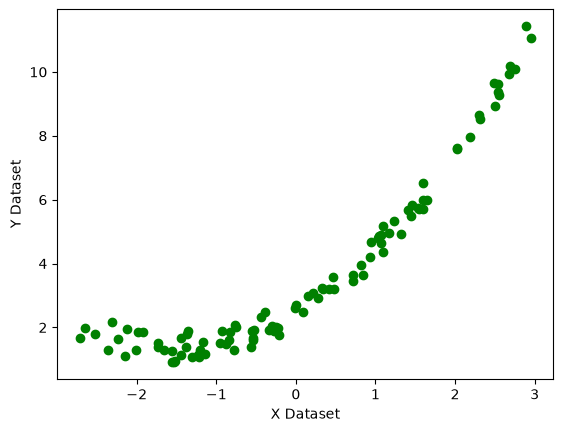

In [2]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.rand(100, 1)

plt.scatter(X, y, color='g')
plt.xlabel('X Dataset')
plt.ylabel('Y Dataset')

plt.show()

## 3. Train-Test Split

Splits `X` and `y` into a training set (80%) and a testing set (20%, `test_size=0.2`), with `random_state=42` fixing the split so it's reproducible.

The model will learn only from the training portion and be judged on the testing portion, which it never sees during fitting.


In [3]:
## Train Test Split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

## 4. Setting Up a Simple (Straight-Line) Linear Regression

Creates a plain `LinearRegression` model called `regression_1`. This will be fit directly on the raw, un-transformed `X` — i.e., it will try to draw a single straight line through clearly curved data, as a baseline to compare against polynomial regression later.


In [4]:
## Implement Simple Linear Regression

from sklearn.linear_model import LinearRegression

regression_1 = LinearRegression()

## 5. Training the Simple Linear Model

Fits `regression_1` on the training data (`X_train`, `y_train`), finding the best straight line: \( y = \beta_0 + \beta_1 X \).


In [5]:
regression_1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[1.68]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[3.6]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[13.69]


## 6. Evaluating the Simple Linear Model — R² Score

Measures how well the straight-line model predicts the unseen test data using the **R² (coefficient of determination)** score.

$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
$$

Since the true data is curved, expect this score to be noticeably lower than what the polynomial models achieve later.


In [6]:
from sklearn.metrics import r2_score

score = r2_score(y_test, regression_1.predict(X_test))
print(score)

0.7940090755199285


## 7. Visualizing the Simple Linear Fit

Plots the straight regression line (red) over the actual training points (green), making it visually obvious that a single straight line can't capture the curve in the data.


Text(0, 0.5, 'Y')

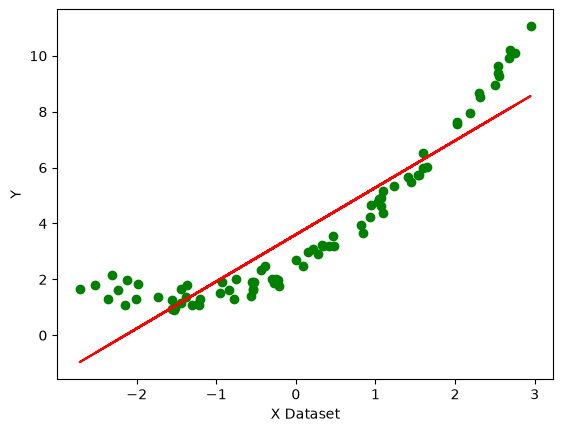

In [7]:
## Vizualize

plt.plot(X_train, regression_1.predict(X_train), color='r')
plt.scatter(X_train, y_train, color='g')

plt.xlabel("X Dataset")
plt.ylabel("Y")

## 8. Importing Polynomial Feature Transformation

Imports `PolynomialFeatures` from scikit-learn — the tool that will let a *linear* model fit a *curved* relationship by expanding the input into polynomial terms (see next cell).


In [8]:
## Apply Polynomial Transformation  (Increases Degree of equations)

from sklearn.preprocessing import PolynomialFeatures

## 9. Transforming Features to Degree 2

Expands each single value of `X` into polynomial terms up to **degree 2**: \([1, X, X^2]\) (the leading `1` comes from `include_bias=True`).

**Why:** `LinearRegression` can only fit straight lines to its inputs. By feeding it \(X^2\) as an extra "feature," it can effectively fit a curved (quadratic) relationship while still being a linear regression under the hood.

**Formula (degree-2 polynomial expansion):**
$$
X \rightarrow [1, X, X^2]
$$


In [9]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

## 10. Inspecting the Transformed Training Features

Displays `X_train_poly` to see the expanded columns \([1, X, X^2]\) produced by the transformation above.


In [10]:
X_train_poly

array([[ 1.00000000e+00, -1.82983030e-03,  3.34827891e-06],
       [ 1.00000000e+00,  3.30389894e-01,  1.09157482e-01],
       [ 1.00000000e+00,  2.17828159e-01,  4.74491070e-02],
       [ 1.00000000e+00, -7.52982299e-01,  5.66982343e-01],
       [ 1.00000000e+00, -1.36665450e+00,  1.86774453e+00],
       [ 1.00000000e+00,  1.23843793e+00,  1.53372850e+00],
       [ 1.00000000e+00, -2.15020951e+00,  4.62340092e+00],
       [ 1.00000000e+00,  1.59568447e+00,  2.54620891e+00],
       [ 1.00000000e+00,  1.09765185e+00,  1.20483958e+00],
       [ 1.00000000e+00, -1.51456413e+00,  2.29390450e+00],
       [ 1.00000000e+00, -9.28108950e-01,  8.61386222e-01],
       [ 1.00000000e+00, -9.52028553e-01,  9.06358366e-01],
       [ 1.00000000e+00,  8.55343848e-02,  7.31613099e-03],
       [ 1.00000000e+00,  2.54014395e+00,  6.45233131e+00],
       [ 1.00000000e+00,  3.35357252e-01,  1.12464486e-01],
       [ 1.00000000e+00, -8.40990519e-01,  7.07265054e-01],
       [ 1.00000000e+00, -2.71567967e+00

## 11. Inspecting the Transformed Test Features

Same check as above, but for the test set — confirms `X_test_poly` has the same expanded structure.


In [11]:
X_test_poly

array([[ 1.00000000e+00,  2.89252162e+00,  8.36668130e+00],
       [ 1.00000000e+00, -1.91627844e+00,  3.67212304e+00],
       [ 1.00000000e+00, -1.14768794e+00,  1.31718760e+00],
       [ 1.00000000e+00, -1.47024963e-02,  2.16163398e-04],
       [ 1.00000000e+00,  7.20406686e-01,  5.18985793e-01],
       [ 1.00000000e+00,  2.49414053e+00,  6.22073701e+00],
       [ 1.00000000e+00, -1.65430598e+00,  2.73672826e+00],
       [ 1.00000000e+00, -1.35593788e+00,  1.83856753e+00],
       [ 1.00000000e+00,  7.22752813e-01,  5.22371629e-01],
       [ 1.00000000e+00,  1.16655044e+00,  1.36083994e+00],
       [ 1.00000000e+00,  1.59746949e+00,  2.55190876e+00],
       [ 1.00000000e+00, -8.24520510e-01,  6.79834071e-01],
       [ 1.00000000e+00,  1.32355738e+00,  1.75180413e+00],
       [ 1.00000000e+00, -7.66480182e-01,  5.87491869e-01],
       [ 1.00000000e+00, -1.73567408e+00,  3.01256450e+00],
       [ 1.00000000e+00,  1.45644176e+00,  2.12122261e+00],
       [ 1.00000000e+00, -8.83470649e-01

## 12. Fitting Polynomial (Degree 2) Regression and Scoring It

Fits a fresh `LinearRegression` model, but this time on the **degree-2 polynomial features** (`X_train_poly`) instead of the raw `X`. Then predicts on `X_test_poly` and evaluates with R².

**Model form being fit:**
$$
y = \beta_0 + \beta_1 X + \beta_2 X^2
$$

Expect this R² score to be higher than the plain straight-line model, since the data is genuinely quadratic.


In [12]:
from sklearn.metrics import r2_score

regression = LinearRegression()
regression.fit(X_train_poly, y_train)

y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.9863549647567771


## 13. Viewing the Learned Coefficients

Prints `regression.coef_` — the learned \(\beta_1\) (coefficient for \(X\)) and \(\beta_2\) (coefficient for \(X^2\)).


In [13]:
print(regression.coef_)

[[0.         1.50878237 0.47341833]]


## 14. Viewing the Learned Intercept

Prints `regression.intercept_` — the learned \(\beta_0\), the value predicted when \(X = 0\).


In [14]:
print(regression.intercept_)

[2.50881327]


## 15. Visual Check — Predicted vs. Actual (Degree 2)

Scatter-plots the model's predictions against the actual training points, to visually confirm the curved fit now tracks the data much more closely than the straight line did.


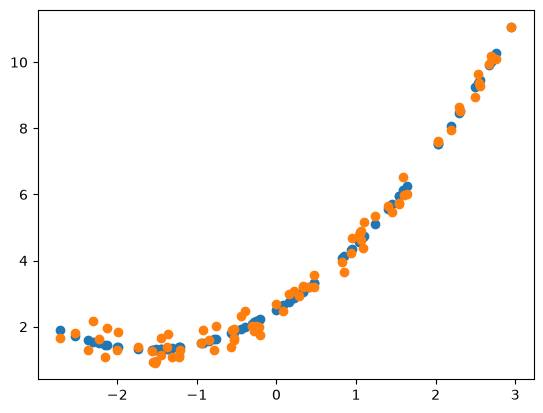

In [15]:
plt.scatter(X_train, regression.predict(X_train_poly))
plt.scatter(X_train, y_train)

## 16. Trying a Higher-Degree Polynomial (Degree 3)

The next section repeats the process with a **degree-3** polynomial to see whether an even more flexible curve improves the fit further, or starts to overfit.


### If Degree = 3

## 17. Transforming Features to Degree 3

Expands `X` into \([1, X, X^2, X^3]\) for both training and test sets.

**Formula (degree-3 polynomial expansion):**
$$
X \rightarrow [1, X, X^2, X^3]
$$


In [16]:
poly = PolynomialFeatures(degree=3, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

## 18. Inspecting the Degree-3 Transformed Features

Displays `X_train_poly` to confirm it now has 4 columns (bias term + \(X, X^2, X^3\)).


In [17]:
X_train_poly

array([[ 1.00000000e+00, -1.82983030e-03,  3.34827891e-06,
        -6.12678219e-09],
       [ 1.00000000e+00,  3.30389894e-01,  1.09157482e-01,
         3.60645291e-02],
       [ 1.00000000e+00,  2.17828159e-01,  4.74491070e-02,
         1.03357516e-02],
       [ 1.00000000e+00, -7.52982299e-01,  5.66982343e-01,
        -4.26927668e-01],
       [ 1.00000000e+00, -1.36665450e+00,  1.86774453e+00,
        -2.55256146e+00],
       [ 1.00000000e+00,  1.23843793e+00,  1.53372850e+00,
         1.89942754e+00],
       [ 1.00000000e+00, -2.15020951e+00,  4.62340092e+00,
        -9.94128060e+00],
       [ 1.00000000e+00,  1.59568447e+00,  2.54620891e+00,
         4.06294601e+00],
       [ 1.00000000e+00,  1.09765185e+00,  1.20483958e+00,
         1.32249438e+00],
       [ 1.00000000e+00, -1.51456413e+00,  2.29390450e+00,
        -3.47426547e+00],
       [ 1.00000000e+00, -9.28108950e-01,  8.61386222e-01,
        -7.99460262e-01],
       [ 1.00000000e+00, -9.52028553e-01,  9.06358366e-01,
      

## 19. Fitting Polynomial (Degree 3) Regression and Scoring It

Fits and evaluates a new `LinearRegression` model on the degree-3 features.

**Model form being fit:**
$$
y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3
$$

Compare this R² score with the degree-2 result — since the true relationship is quadratic, degree 3 may not meaningfully improve (or could very slightly overfit) compared to degree 2.


In [18]:
from sklearn.metrics import r2_score

regression = LinearRegression()
regression.fit(X_train_poly, y_train)

y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.9852728827735447


## 20. Predicting on a Fresh, Evenly-Spaced Dataset

Creates a brand-new set of 200 evenly-spaced `X` values from -3 to 3 (`X_new`), transforms them the same way with the already-fitted `poly` object (`poly.transform`, not `fit_transform` — important, since we reuse the transformation learned on the training data), and displays the result.

**Why:** Evenly-spaced points make for a smooth curve when plotted, which is ideal for visualizing what the fitted polynomial function looks like across the whole input range.


In [19]:
## Predict New Dataset

X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)

X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

## 21. Plotting the Fitted Curve Against Training and Test Points

Uses the degree-3 model to predict `y_new` for the smooth `X_new` grid, then plots:
- the fitted curve (red line),
- the original training points (blue dots),
- the original test points (green dots),

all on one chart, to visually judge how well the curve matches both the training and unseen test data.


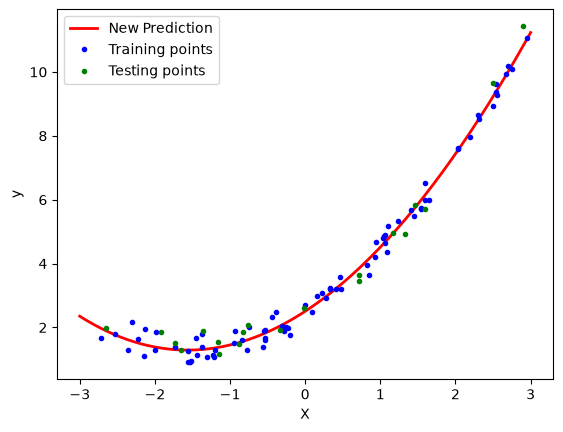

In [20]:
y_new = regression.predict(X_new_poly)

plt.plot(X_new, y_new, "-r", linewidth=2, label="New Prediction")
plt.plot(X_train, y_train, "b.", label="Training points")
plt.plot(X_test, y_test, "g.", label="Testing points")

plt.xlabel("X")
plt.ylabel("y")
plt.legend()

plt.show()